In [8]:
# first step : based on the main link 
#       |_ get all the url to each movie script page after loading all the movie available in the main page

# second step : based on each movie script page link
#       |_ get the pdf url to download the script before passing it to the ocr. 
#       |_ download the script pdf file in the docker volume dedicated to scrapping scripts        

import pandas as pd
import time
# Selenium : web navigation and scrapping
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

# Selenium driver
chrome_options = webdriver.ChromeOptions()
chrome_options.add_argument('--headless')
chrome_options.add_argument('--no-sandbox')
chrome_options.add_argument('--verbose')

DRIVER = webdriver.Chrome(chrome_options)
DRIVER.set_window_rect(0,0,1280,840)

{'height': 840, 'width': 1280, 'x': 0, 'y': 0}

In [9]:
def handle_consent_popup(driver):    
    try:
        # Wait for the consent button to be clickable
        consent_button = WebDriverWait(driver, 2).until(
            EC.element_to_be_clickable((By.XPATH, "/html/body/div[5]/div[2]/div[2]/div[3]/div[2]/button[1]"))
        )
        # Click the consent button
        consent_button.click()
    except Exception as e:
        print("Could not find or click the consent button:", e) 

In [10]:

def load_all_data(DRIVER) :  
    while True :
        try :
            load_more_script_button = DRIVER.find_element(By.XPATH, '//*[@id="scriptsList"]/div[6]/button')  
            DRIVER.execute_script("arguments[0].scrollIntoView({block: 'center', inline: 'center'});", load_more_script_button)
            load_more_script_button.click()
            time.sleep(2)
        except Exception as e :
            print("No more 'Load More' button to click :", e)
            break

In [11]:
def get_all_movie_script_page_urls(DRIVER) :
    movie_list_container = DRIVER.find_element(By.XPATH, '//*[@id="scriptsList"]/div[3]')
    movie_list_web_elem = movie_list_container.find_elements(By.TAG_NAME, 'a')

    movie_name_list_web_element = DRIVER.find_elements(By.XPATH, '//*[@id="scriptsList"]/div[3]/a/div/p[1]')
    movie_name_list = [movie_name.get_attribute('innerText') for movie_name in movie_name_list_web_element]

    url_list = [movie.get_attribute('href') for movie in movie_list_web_elem]
    return url_list, movie_name_list

In [12]:
def get_pdf_script_url(url) :
    DRIVER.get(url)
    try : 
        pdf_script_web_elem = DRIVER.find_element(By.XPATH, '/html/body/main/div/div/article/div/div[2]/div[1]/div[1]/a')
        pdf_script_url = pdf_script_web_elem.get_attribute('href')
        return pdf_script_url  
    except Exception as e :
        print("No pdf script url found for this url movie script page :", url)
        print('error :', e)
        return None

In [13]:
from IPython.display import Image
def screenshot():
  screenshot = DRIVER.get_screenshot_as_png()
  display(Image(screenshot, width = '700'))

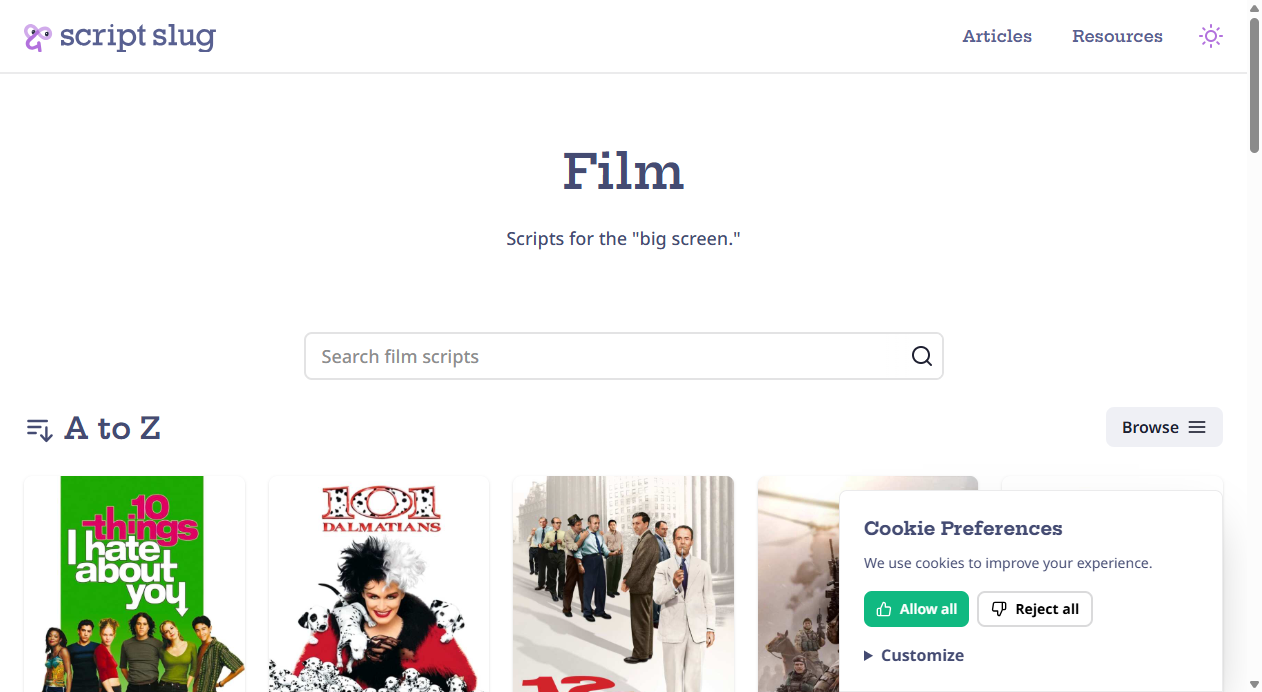

In [15]:

DRIVER.get('https://www.scriptslug.com/scripts/medium/film?sort=az')
handle_consent_popup(DRIVER)
screenshot()


No more 'Load More' button to click : Message: no such element: Unable to locate element: {"method":"xpath","selector":"//*[@id="scriptsList"]/div[6]/button"}
  (Session info: chrome=142.0.7444.163); For documentation on this error, please visit: https://www.selenium.dev/documentation/webdriver/troubleshooting/errors#nosuchelementexception
Stacktrace:
Symbols not available. Dumping unresolved backtrace:
	0x7ff7547fa235
	0x7ff754552650
	0x7ff7542e16dd
	0x7ff75433a27e
	0x7ff75433a58c
	0x7ff75438ed77
	0x7ff75438baba
	0x7ff75432b0ed
	0x7ff75432bf63
	0x7ff754825d60
	0x7ff75481fe8a
	0x7ff754841005
	0x7ff75456d73e
	0x7ff754574e3f
	0x7ff75455b7e4
	0x7ff75455b99f
	0x7ff754541908
	0x7ffb56ec259d
	0x7ffb5864af78



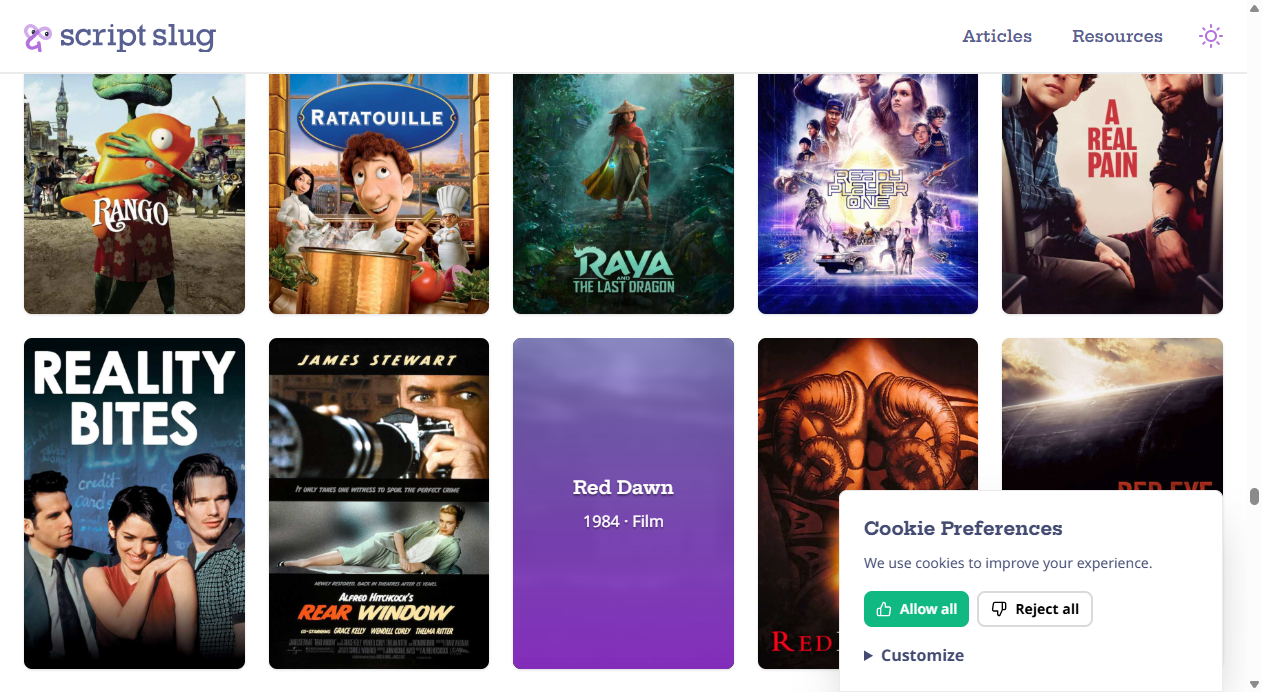

In [ ]:
load_all_data(DRIVER)      # + of 20 min.
url_list, movie_name_list = get_all_movie_script_page_urls(DRIVER=DRIVER)
screenshot()

In [20]:
print(url_list)
print(movie_name_list)
print(len(url_list), len(movie_name_list))  # 1196 1196

['https://www.scriptslug.com/script/10-things-i-hate-about-you-1999', 'https://www.scriptslug.com/script/101-dalmations-1996', 'https://www.scriptslug.com/script/12-angry-men-1957', 'https://www.scriptslug.com/script/12-strong-2018', 'https://www.scriptslug.com/script/12-years-a-slave-2013', 'https://www.scriptslug.com/script/127-hours-2010', 'https://www.scriptslug.com/script/1408-2007', 'https://www.scriptslug.com/script/16-blocks-2006', 'https://www.scriptslug.com/script/1917-2019', 'https://www.scriptslug.com/script/2-fast-2-furious-2003', 'https://www.scriptslug.com/script/2001-a-space-odyssey-1968', 'https://www.scriptslug.com/script/2010-the-year-we-make-contact-1984', 'https://www.scriptslug.com/script/20th-century-girl-2022', 'https://www.scriptslug.com/script/20th-century-women-2016', 'https://www.scriptslug.com/script/21-jump-street-2012', 'https://www.scriptslug.com/script/213-2009', 'https://www.scriptslug.com/script/22-july-2018', 'https://www.scriptslug.com/script/22-jum

In [21]:
df_scripts_slug = pd.DataFrame({
    'movie_name' : movie_name_list,
    'script_page_url' : url_list
})


In [22]:
df_scripts_slug["pdf_url"] = df_scripts_slug["script_page_url"].apply(get_pdf_script_url)   # 13min jusqu a la lettre 'g'
df_scripts_slug.head()

No pdf script url found for this url movie script page : https://www.scriptslug.com/script/fighting-with-my-family-2019
error : Message: no such element: Unable to locate element: {"method":"xpath","selector":"/html/body/main/div/div/article/div/div[2]/div[1]/div[1]/a"}
  (Session info: chrome=142.0.7444.163); For documentation on this error, please visit: https://www.selenium.dev/documentation/webdriver/troubleshooting/errors#nosuchelementexception
Stacktrace:
Symbols not available. Dumping unresolved backtrace:
	0x7ff7547fa235
	0x7ff754552650
	0x7ff7542e16dd
	0x7ff75433a27e
	0x7ff75433a58c
	0x7ff75438ed77
	0x7ff75438baba
	0x7ff75432b0ed
	0x7ff75432bf63
	0x7ff754825d60
	0x7ff75481fe8a
	0x7ff754841005
	0x7ff75456d73e
	0x7ff754574e3f
	0x7ff75455b7e4
	0x7ff75455b99f
	0x7ff754541908
	0x7ffb56ec259d
	0x7ffb5864af78



,movie_name,script_page_url,pdf_url
0,10 Things I Hate About You,https://www.scriptslug.com/script/10-things-i-...,https://assets.scriptslug.com/live/pdf/scripts...
1,101 Dalmations,https://www.scriptslug.com/script/101-dalmatio...,https://assets.scriptslug.com/live/pdf/scripts...
2,12 Angry Men,https://www.scriptslug.com/script/12-angry-men...,https://assets.scriptslug.com/live/pdf/scripts...
3,12 Strong,https://www.scriptslug.com/script/12-strong-2018,https://assets.scriptslug.com/live/pdf/scripts...
4,12 Years a Slave,https://www.scriptslug.com/script/12-years-a-s...,https://assets.scriptslug.com/live/pdf/scripts...


In [23]:

df_scripts_slug.to_csv('scripts_slug_movie_script_page_urls.csv', index=False)

In [27]:
print(len(df_scripts_slug))

660


In [ ]:
DRIVER.quit()